# KVPE vs Sequential Position Encoding Ablation

Demonstrates that KVPE (Key-Value Position Encoding) is critical for nested structures
with repeated field names at different paths.

## Toy dataset

Deeply nested all-boolean records:

```json
{
  "a": {"left": {"val": true},  "right": {"val": false}},
  "b": {"left": {"val": false}, "right": {"val": true}},
  "c": {"left": {"val": true},  "right": {"val": false}},
  "d": {"left": {"val": true},  "right": {"val": false}}
}
```

- **8 leaf booleans** per record, all at depth 3, all named `"val"`
- `"left"` and `"right"` each appear 4 times; `"a"` through `"d"` appear once each
- Each unique path (e.g., `a.left.val`) has a **distinct P(True)**
- With `shuffle_keys=True`, key order is randomized at every nesting level

**Why this breaks sequential PE**: The token `"val" : true` appears 8 times per record in identical form.
Sequential PE must compose multi-hop attention (val → left/right → a/b/c/d) to identify which path
it's on, and shuffled key order makes positions uninformative. KVPE encodes the full path `$.a.left.val` directly.

In [ ]:
import random

import numpy as np
import torch

NUM_DOCS = 5000
SEEDS = [42, 123, 456]

# Each path has a distinct P(True) — spread across [0.05, 0.95]
LEAF_PROBS = {
    ("a", "left", "val"): 0.95,
    ("a", "right", "val"): 0.30,
    ("b", "left", "val"): 0.05,
    ("b", "right", "val"): 0.70,
    ("c", "left", "val"): 0.85,
    ("c", "right", "val"): 0.15,
    ("d", "left", "val"): 0.60,
    ("d", "right", "val"): 0.40,
}

ALL_PATHS = list(LEAF_PROBS.keys())
BRANCHES = ["a", "b", "c", "d"]
SIDES = ["left", "right"]


def generate_dataset(n, seed=42):
    rng = np.random.RandomState(seed)
    docs = []
    for _ in range(n):
        doc = {}
        for branch in BRANCHES:
            doc[branch] = {}
            for side in SIDES:
                p = LEAF_PROBS[(branch, side, "val")]
                doc[branch][side] = {"val": bool(rng.binomial(1, p))}
        docs.append(doc)
    return docs


docs = generate_dataset(NUM_DOCS, seed=42)

# Verify ground truth statistics
print(f"Dataset size: {NUM_DOCS}")
print("Leaves per record: 8\n")
print(f"{'Path':<20s}  {'Expected':>8s}  {'Actual':>8s}")
print("-" * 40)
for path, expected_p in LEAF_PROBS.items():
    branch, side, _ = path
    values = [d[branch][side]["val"] for d in docs]
    actual = np.mean(values)
    print(f"{'.'.join(path):<20s}  {expected_p:>8.3f}  {actual:>8.3f}")

print("\nSample doc:")
print(f"  {docs[0]}")

Dataset size: 5000
Leaves per record: 8

Path                  Expected    Actual
----------------------------------------
a.left.val               0.950     0.951
a.right.val              0.300     0.287
b.left.val               0.050     0.050
b.right.val              0.700     0.692
c.left.val               0.850     0.850
c.right.val              0.150     0.152
d.left.val               0.600     0.591
d.right.val              0.400     0.399

Sample doc:
  {'a': {'left': {'val': True}, 'right': {'val': True}}, 'b': {'left': {'val': False}, 'right': {'val': True}}, 'c': {'left': {'val': True}, 'right': {'val': False}}, 'd': {'left': {'val': True}, 'right': {'val': True}}}


## Model Configuration

In [ ]:
from origami import (
    DataConfig,
    InferenceConfig,
    ModelConfig,
    OrigamiConfig,
    OrigamiPipeline,
    TrainingConfig,
)
from origami.training import TrainerCallback


class HistoryCallback(TrainerCallback):
    """Records per-epoch train and val loss."""

    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, trainer, state, epoch_stats):
        self.train_losses.append(epoch_stats.loss)

    def on_evaluate(self, trainer, state, metrics):
        if "val_loss" in metrics:
            self.val_losses.append(metrics["val_loss"])


def make_config(position_encoding="kvpe"):
    return OrigamiConfig(
        data=DataConfig(
            numeric_mode="disabled",
            infer_schema=True,
        ),
        model=ModelConfig(
            d_model=32,
            n_heads=4,
            n_layers=2,
            d_ff=128,
            dropout=0.0,
            position_encoding=position_encoding,
        ),
        training=TrainingConfig(
            batch_size=64,
            learning_rate=1e-4,
            warmup_steps=50,
            num_epochs=50,
            constrain_grammar=True,
            constrain_schema=True,
            shuffle_keys=True,
        ),
        inference=InferenceConfig(
            constrain_grammar=True,
            constrain_schema=True,
        ),
    )


print(f"KVPE params:       {OrigamiPipeline(make_config('kvpe')).preprocess(docs[:10])._model.get_num_parameters():,}")
print(
    f"Sequential params: {OrigamiPipeline(make_config('sequential')).preprocess(docs[:10])._model.get_num_parameters():,}"
)

Numba available: True
KVPE params:       34,899
Sequential params: 92,243


## Training (3 seeds × 2 PE methods)

In [3]:
train_docs = docs[:4000]
eval_docs = docs[4000:]

# Store results per (pe_type, seed)
pipelines = {}  # (pe_type, seed) -> pipeline
histories = {}  # (pe_type, seed) -> HistoryCallback

for seed in SEEDS:
    for pe_type in ["kvpe", "sequential"]:
        print(f"\n{'=' * 60}")
        print(f"Training {pe_type.upper()} | seed={seed}")
        print(f"{'=' * 60}")

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        config = make_config(pe_type)
        pipeline = OrigamiPipeline(config)
        history = HistoryCallback()

        pipeline.fit(train_docs, eval_data=eval_docs, verbose=True, callbacks=[history])

        pipelines[(pe_type, seed)] = pipeline
        histories[(pe_type, seed)] = history

print(f"\nTrained {len(pipelines)} models.")


Training KVPE | seed=42
Infer schema: True
Vocabulary size: 19
Model parameters: 34,899
Training device: mps

Training SEQUENTIAL | seed=42
Infer schema: True
Vocabulary size: 19
Model parameters: 92,243
Training device: mps

Training KVPE | seed=123
Infer schema: True
Vocabulary size: 19
Model parameters: 34,899
Training device: mps

Training SEQUENTIAL | seed=123
Infer schema: True
Vocabulary size: 19
Model parameters: 92,243
Training device: mps

Training KVPE | seed=456
Infer schema: True
Vocabulary size: 19
Model parameters: 34,899
Training device: mps

Training SEQUENTIAL | seed=456
Infer schema: True
Vocabulary size: 19
Model parameters: 92,243
Training device: mps

Trained 6 models.


## Training Loss Curves

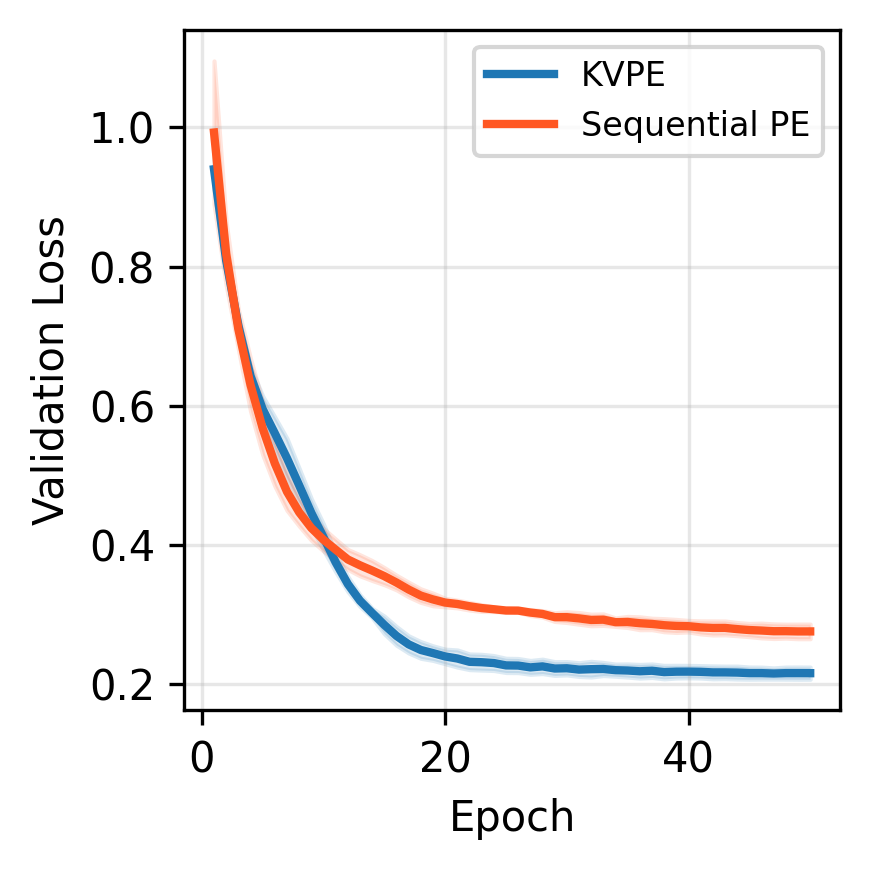

In [4]:
import matplotlib.pyplot as plt

colors = {"kvpe": "#1f77b4", "sequential": "#FF5722"}

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

for pe_type in ["kvpe", "sequential"]:
    all_curves = np.array([histories[(pe_type, s)].val_losses for s in SEEDS])
    epochs = np.arange(1, all_curves.shape[1] + 1)
    mean = all_curves.mean(axis=0)
    std = all_curves.std(axis=0)

    ax.plot(
        epochs, mean, color=colors[pe_type], label={"kvpe": "KVPE", "sequential": "Sequential PE"}[pe_type], linewidth=2
    )
    ax.fill_between(epochs, mean - std, mean + std, color=colors[pe_type], alpha=0.15)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig("kvpe_ablation_val_loss.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Generate Synthetic Data

In [5]:
N_SAMPLES = 2000

all_samples = {}  # (pe_type, seed) -> list of samples

for seed in SEEDS:
    for pe_type in ["kvpe", "sequential"]:
        print(f"Generating from {pe_type.upper()} | seed={seed}...")
        samples = pipelines[(pe_type, seed)].generate(num_samples=N_SAMPLES, temperature=1.0)
        all_samples[(pe_type, seed)] = samples
        print(f"  {len(samples)} samples generated")

print(f"\nTotal: {len(all_samples)} sample sets")

Generating from KVPE | seed=42...
  2000 samples generated
Generating from SEQUENTIAL | seed=42...
  2000 samples generated
Generating from KVPE | seed=123...
  2000 samples generated
Generating from SEQUENTIAL | seed=123...
  2000 samples generated
Generating from KVPE | seed=456...
  2000 samples generated
Generating from SEQUENTIAL | seed=456...
  2000 samples generated

Total: 6 sample sets


In [6]:
def extract_leaf(sample, branch, side):
    """Safely extract val from sample[branch][side]['val']."""
    try:
        v = sample[branch][side]["val"]
        if isinstance(v, bool):
            return v
    except (KeyError, TypeError):
        pass
    return None


def compute_path_marginals(samples):
    """Compute P(val=True) for each path."""
    results = {}
    for path, true_p in LEAF_PROBS.items():
        branch, side, _ = path
        values = [v for s in samples if (v := extract_leaf(s, branch, side)) is not None]
        p = np.mean(values) if values else float("nan")
        results[path] = {"true_p": true_p, "gen_p": p, "n": len(values)}
    return results


# Compute marginals for all (pe_type, seed) combinations
all_marginals = {}
for key, samples in all_samples.items():
    all_marginals[key] = compute_path_marginals(samples)

## Per-Path Marginals

Each of the 8 leaf paths (`a.left.val`, `a.right.val`, ...) has a distinct P(True).
Can each model reproduce the correct marginal for each path?

In [7]:
paths = list(LEAF_PROBS.keys())
labels = [".".join(p) for p in paths]


# Gather per-path generated P across seeds
def gather_gen_p(pe_type):
    """Returns (n_paths,) mean and (n_paths,) std across seeds."""
    per_seed = np.array([[all_marginals[(pe_type, s)][p]["gen_p"] for p in paths] for s in SEEDS])
    return per_seed.mean(axis=0), per_seed.std(axis=0)


kvpe_mean, kvpe_std = gather_gen_p("kvpe")
seq_mean, seq_std = gather_gen_p("sequential")
true_vals = np.array([LEAF_PROBS[p] for p in paths])

# Print table
print(f"{'Path':<20s}  {'True P':>7s}  {'KVPE':>12s}  {'Seq':>12s}")
print("-" * 60)
for i, path in enumerate(paths):
    print(
        f"{labels[i]:<20s}  {true_vals[i]:>7.3f}"
        f"  {kvpe_mean[i]:>5.3f}±{kvpe_std[i]:.3f}"
        f"  {seq_mean[i]:>5.3f}±{seq_std[i]:.3f}"
    )

kvpe_mae_per_seed = [
    np.mean([abs(all_marginals[("kvpe", s)][p]["gen_p"] - LEAF_PROBS[p]) for p in paths]) for s in SEEDS
]
seq_mae_per_seed = [
    np.mean([abs(all_marginals[("sequential", s)][p]["gen_p"] - LEAF_PROBS[p]) for p in paths]) for s in SEEDS
]
print("-" * 60)
print(
    f"{'MAE':<20s}  {'':>7s}  {np.mean(kvpe_mae_per_seed):>5.3f}±{np.std(kvpe_mae_per_seed):.3f}  {np.mean(seq_mae_per_seed):>5.3f}±{np.std(seq_mae_per_seed):.3f}"
)

Path                   True P          KVPE           Seq
------------------------------------------------------------
a.left.val              0.950  0.941±0.006  0.527±0.022
a.right.val             0.300  0.284±0.008  0.479±0.020
b.left.val              0.050  0.059±0.004  0.496±0.017
b.right.val             0.700  0.679±0.004  0.474±0.025
c.left.val              0.850  0.857±0.011  0.530±0.027
c.right.val             0.150  0.152±0.007  0.480±0.020
d.left.val              0.600  0.571±0.005  0.514±0.026
d.right.val             0.400  0.397±0.007  0.473±0.017
------------------------------------------------------------
MAE                            0.014±0.003  0.260±0.011


## Per-Path Marginal Comparison

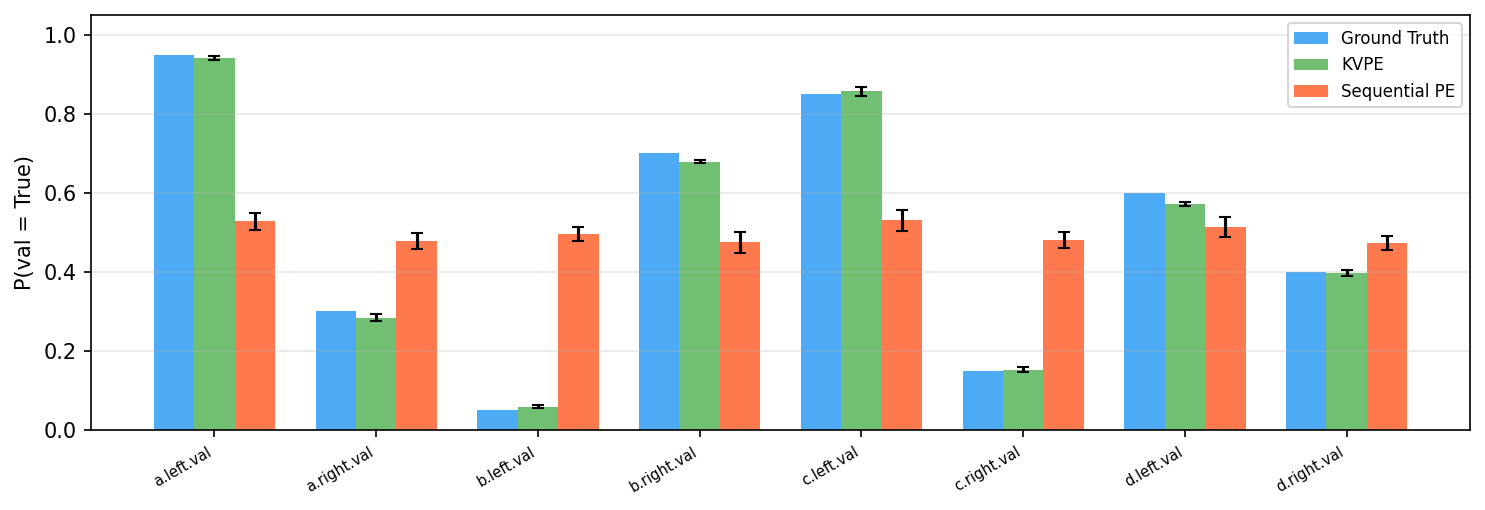

In [8]:
x = np.arange(len(paths))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=150)
ax.bar(x - width, true_vals, width, label="Ground Truth", color="#2196F3", alpha=0.8)
ax.bar(x, kvpe_mean, width, yerr=kvpe_std, capsize=3, label="KVPE", color="#4CAF50", alpha=0.8)
ax.bar(x + width, seq_mean, width, yerr=seq_std, capsize=3, label="Sequential PE", color="#FF5722", alpha=0.8)

ax.set_ylabel("P(val = True)")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Absolute Marginal Error

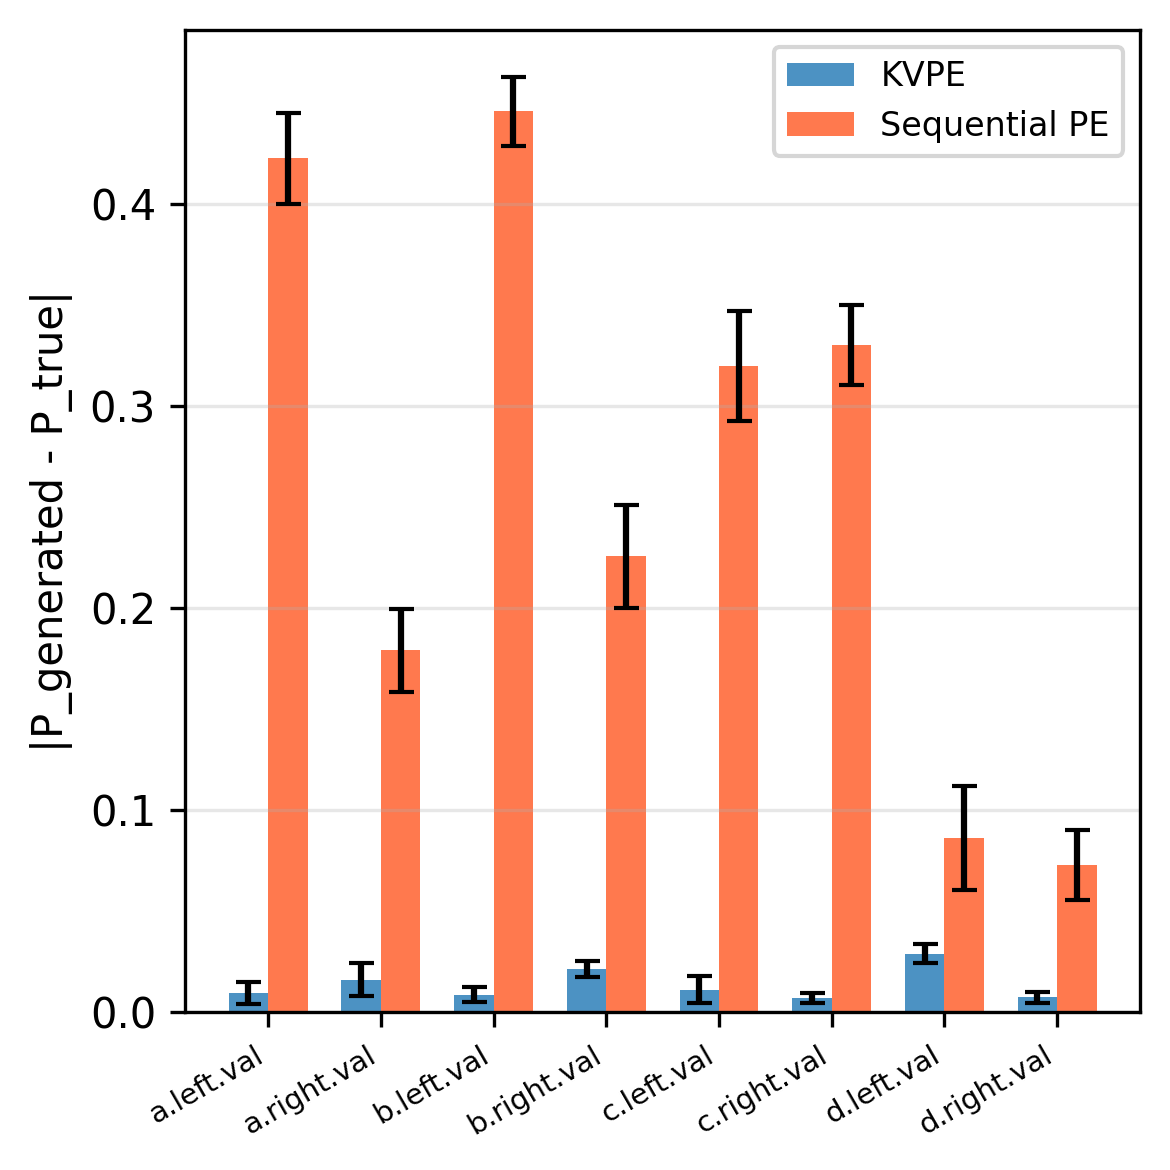

In [9]:
kvpe_errs_per_seed = np.array(
    [[abs(all_marginals[("kvpe", s)][p]["gen_p"] - LEAF_PROBS[p]) for p in paths] for s in SEEDS]
)
seq_errs_per_seed = np.array(
    [[abs(all_marginals[("sequential", s)][p]["gen_p"] - LEAF_PROBS[p]) for p in paths] for s in SEEDS]
)

kvpe_err_mean = kvpe_errs_per_seed.mean(axis=0)
kvpe_err_std = kvpe_errs_per_seed.std(axis=0)
seq_err_mean = seq_errs_per_seed.mean(axis=0)
seq_err_std = seq_errs_per_seed.std(axis=0)

x = np.arange(len(paths))
width = 0.35

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
ax.bar(x - width / 2, kvpe_err_mean, width, yerr=kvpe_err_std, capsize=3, label="KVPE", color="#1f77b4", alpha=0.8)
ax.bar(
    x + width / 2, seq_err_mean, width, yerr=seq_err_std, capsize=3, label="Sequential PE", color="#FF5722", alpha=0.8
)

ax.set_ylabel("|P_generated - P_true|")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.tight_layout()
fig.savefig("kvpe_ablation_ame.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

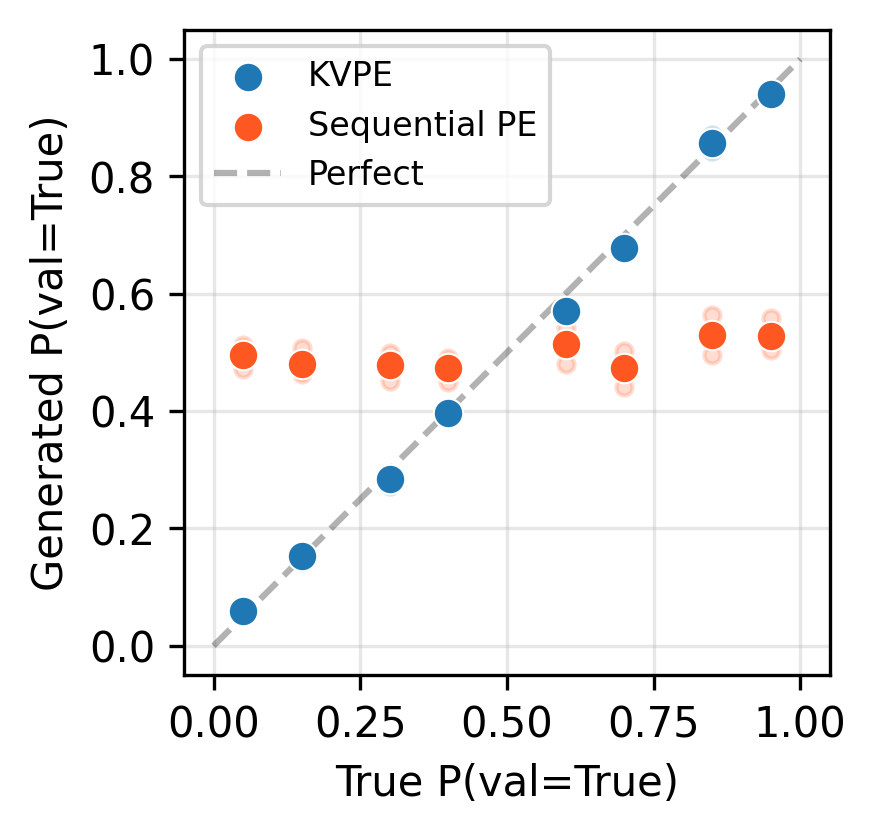

In [10]:
pe_labels = {"kvpe": "KVPE", "sequential": "Sequential PE"}

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

for pe_type in ["kvpe", "sequential"]:
    mean_p, std_p = gather_gen_p(pe_type)

    # Individual seeds as faint points
    for s in SEEDS:
        gen_p = [all_marginals[(pe_type, s)][p]["gen_p"] for p in paths]
        ax.scatter(true_vals, gen_p, s=15, alpha=0.2, color=colors[pe_type], zorder=2)

    # Mean as bold points
    ax.scatter(
        true_vals,
        mean_p,
        s=50,
        color=colors[pe_type],
        zorder=3,
        edgecolors="white",
        linewidths=0.5,
        label=pe_labels[pe_type],
    )

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
ax.set_xlabel("True P(val=True)")
ax.set_ylabel("Generated P(val=True)")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
fig.savefig("kvpe_ablation_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()